# HCDE 530 — Week 5

Starter notebook for exercises and exploration. CSVs in this folder include `tmdb_popular_2025.csv`, `tmdb_recent_movies.csv`, `app_info.csv`, `reviews_mini.csv`, and `app_reviews_demo.csv`. See `week5_pandas_demo.ipynb` and `week5_merge_demo.ipynb` for guided demos.

## Setup

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## Load data

Use **`tmdb_popular_2025.csv`**. Run this notebook with the working directory set to the **`week 5`** folder so the relative path below resolves (or change the path to match your machine).

In [5]:
# Load the MP1 dataset: one row per popular 2025 TMDB film with ratings and metadata.
movies = pd.read_csv("week 5/tmdb_popular_2025.csv")

# Preview the first rows — answers "what columns exist and do example values look sensible?"
movies.head()

,movie_id,title,release_date,vote_average,vote_count,popularity,overview
0,83533,Avatar: Fire and Ash,2025-12-17,7.375,2755,215.0432,In the wake of the devastating war against the...
1,1352874,The Crucifix: Blood of the Exorcist,2025-01-09,6.000,30,146.6369,A gruesome discovery in the grounds of their n...
2,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.700,811,123.6656,The Demon Slayer Corps are drawn into the Infi...
3,1084242,Zootopia 2,2025-11-26,7.609,2622,99.4523,After cracking the biggest case in Zootopia's ...
4,1242898,Predator: Badlands,2025-11-05,7.689,2684,90.0856,"Cast out from his clan, a young Predator finds..."


In [6]:
# Summarize dtypes, row count, and non-null counts — tells whether any column is empty or typed wrong.
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_id      50 non-null     int64  
 1   title         50 non-null     str    
 2   release_date  50 non-null     str    
 3   vote_average  50 non-null     float64
 4   vote_count    50 non-null     int64  
 5   popularity    50 non-null     float64
 6   overview      50 non-null     str    
dtypes: float64(2), int64(2), str(3)
memory usage: 2.9 KB


## Value counts (category frequency)

How many films in this snapshot released in each calendar month? **`value_counts`** answers which months dominate the list (not average quality — just how often each month appears).

In [7]:
# Derive month from release_date so we can treat it as a discrete category.
movies["release_month"] = pd.to_datetime(movies["release_date"]).dt.month

# Count rows per month — answers "which release months show up most often in this top-50 list?"
movies["release_month"].value_counts().sort_index()

release_month
1     2
2     1
3     2
4     1
5     3
6     4
7     6
8     3
9     5
10    6
11    9
12    8
Name: count, dtype: int64

## 1. Distribution of the most important column

`popularity` is TMDB's headline ranking signal — it captures how much attention each title is getting right now. Looking at its distribution shows whether the list is dominated by a few breakout hits or spread evenly across many films.

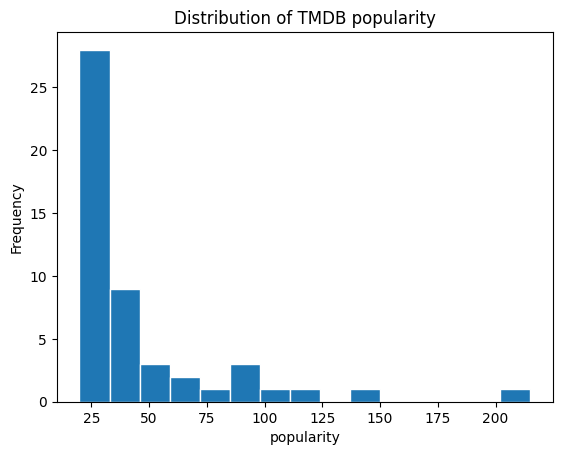

count     50.000000
mean      45.143330
std       37.401721
min       19.873300
25%       24.269650
50%       28.928350
75%       45.737225
max      215.043200
Name: popularity, dtype: float64

In [8]:
# Visual summary of how TMDB popularity spreads — answers "is attention concentrated in a few titles or spread out?"
movies["popularity"].plot.hist(bins=15, edgecolor="white")
plt.xlabel("popularity")
plt.title("Distribution of TMDB popularity")
plt.show()

# Numeric summary (mean, spread, extremes) for the same column.
movies["popularity"].describe()

## 2. A meaningful subset

A `vote_average` from only a handful of votes is noisy. Filtering to movies with at least 500 votes leaves the titles whose ratings are backed by a large enough audience to be informative.

In [9]:
# Keep only films with enough votes that the average rating is less noisy — answers "which titles have trustworthy scores?"
well_voted = movies[movies["vote_count"] >= 500]
print(f"{well_voted.shape[0]} of {movies.shape[0]} movies kept")

# Show what's left: still-popular 2025 films, but with stronger rating evidence.
well_voted[["title", "release_date", "vote_average", "vote_count", "popularity"]].head(10)

34 of 50 movies kept


,title,release_date,vote_average,vote_count,popularity
0,Avatar: Fire and Ash,2025-12-17,7.375,2755,215.0432
2,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.700,811,123.6656
3,Zootopia 2,2025-11-26,7.609,2622,99.4523
4,Predator: Badlands,2025-11-05,7.689,2684,90.0856
5,The Shadow's Edge,2025-08-16,7.212,595,87.1121
6,The Housemaid,2025-12-18,7.230,1949,86.6010
8,Anaconda,2025-12-24,5.900,1070,69.5705
9,War of the Worlds,2025-07-29,4.139,968,69.5574
12,Jurassic World Rebirth,2025-07-01,6.300,3253,46.4256
13,KPop Demon Hunters,2025-06-20,8.000,2680,43.6721


## 3. Group by a category and average a numeric column

The dataset has no genre column, so the natural category here is the **release month**, derived from `release_date`. Grouping by month and averaging `vote_average` and `popularity` shows how 2025's reception varies across the year.

In [10]:
# release_month was added in the value_counts cell above.

# Average rating and popularity by release month — answers "does average reception differ by time of year?"
monthly = (
    movies.groupby("release_month")[["vote_average", "popularity"]]
    .mean()
    .round(2)
    .sort_index()
)
monthly

,vote_average,popularity
release_month,,
1,7.06,87.86
2,7.62,31.21
3,6.80,27.94
4,7.47,36.75
5,6.57,34.06
6,7.73,30.92
7,6.59,54.60
8,7.03,44.83
9,7.29,45.24


## 4. Missing values

`info()` already hinted that this snapshot is fully populated, but it's worth confirming column-by-column. If any column had gaps, those rows would surface here.

In [11]:
# Per-column missing counts — answers "which fields are incomplete?" (.isnull() same as .isna() in pandas)
missing_per_column = movies.isnull().sum()
print(f"Total missing cells: {missing_per_column.sum()}")
missing_per_column

Total missing cells: 0


movie_id         0
title            0
release_date     0
vote_average     0
vote_count       0
popularity       0
overview         0
release_month    0
dtype: int64